

# Project : Semantic Caching and Cost-Aware Routing for LLMs

Cut LLM cost and latency with two ideas: a semantic cache (reuse answers for similar questions) and a cost-aware router (cheap model for easy questions, strong model for hard ones). Every saving is shown next to answer quality, because a cheaper wrong answer is not a saving.

## What this notebook does
- Builds a semantic cache using sentence embeddings and cosine similarity, with an optional number guard
- Builds a router that sends easy questions to a small model and hard ones to a big model, with escalation when the cheap answer looks bad (the reason is logged)
- Runs 39 questions (13 groups, 3 phrasings each) through 4 setups: always strong, router only, router + cache, router + cache + number guard
- Includes near-duplicate trap questions (15% of 240 vs 250, Australia vs Austria) that should NOT share a cached answer
- Checks answer quality with keyword checks, and reports cost per correct answer
- Tests different similarity thresholds without extra API calls

## How to run
1. Upload this file to Google Colab (or open it from Drive)
2. Runtime → Run all, or run each cell one by one
3. If a step fails, run the cell again, then restart the runtime once and run again
4. Prices in Step 3 come from the Groq pricing page for the two gpt-oss models. The price for llama-3.1-8b-instant comes from a third-party price list, so check groq.com/pricing and edit the table if you want exact numbers. This notebook makes about 140 API calls, so it takes several minutes.

## Step 1: Install libraries

In [1]:
!pip install -q sentence-transformers openai pandas numpy matplotlib

## Step 2: Connect to Groq (the AI part)
Paste your Groq API key when it asks. The key is hidden while you type.

In [2]:
import time
from getpass import getpass
from openai import OpenAI

GROQ_KEY = getpass("Paste your Groq API key: ")
client = OpenAI(api_key=GROQ_KEY, base_url="https://api.groq.com/openai/v1")
MODEL = "openai/gpt-oss-120b"

def ask_llm(question, system="You are a helpful analyst.", model=MODEL):
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": system}, {"role": "user", "content": question}],
                max_tokens=1500,
                temperature=0.3,
            )
            return r.choices[0].message.content
        except Exception as e:
            print("llm error, trying again:", str(e)[:100])
            time.sleep(5)
    return "LLM not available right now."

print(ask_llm("Say hi in five words."))

Paste your Groq API key: ··········
Hi there, how are you?


## Step 3: Settings
Two models: a cheap one and a strong one. The notebook tries `llama-3.1-8b-instant` as the cheap model and falls back to `gpt-oss-20b` if it is not available on your account. Prices are per 1 million tokens (edit them if they change).

In [3]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"
import re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

STRONG_MODEL = "openai/gpt-oss-120b"
CHEAP_CHOICES = ["llama-3.1-8b-instant", "openai/gpt-oss-20b"]

def model_works(model):
    try:
        client.chat.completions.create(model=model, messages=[{"role": "user", "content": "Say OK"}], max_tokens=200)
        return True
    except Exception as e:
        print(model, "not available:", str(e)[:80])
        return False

CHEAP_MODEL = CHEAP_CHOICES[-1]
for m in CHEAP_CHOICES:
    if model_works(m):
        CHEAP_MODEL = m
        break
print("Cheap model:", CHEAP_MODEL, "| Strong model:", STRONG_MODEL)

prices = {
    "llama-3.1-8b-instant": {"input": 0.05, "output": 0.08},
    "openai/gpt-oss-20b": {"input": 0.10, "output": 0.50},
    "openai/gpt-oss-120b": {"input": 0.15, "output": 0.75},
}
SIM_THRESHOLD = 0.85
ROUTER_THRESHOLD = 1.5

def call_model(model, question):
    start = time.time()
    text = ""
    in_tok = 0
    out_tok = 0
    for tries in range(3):
        try:
            r = client.chat.completions.create(
                model=model,
                messages=[{"role": "system", "content": "Answer clearly in under 80 words."},
                          {"role": "user", "content": question}],
                max_tokens=1200, temperature=0.2)
            text = r.choices[0].message.content or ""
            in_tok = r.usage.prompt_tokens
            out_tok = r.usage.completion_tokens
            break
        except Exception as e:
            print("error, retrying:", str(e)[:80])
            time.sleep(4)
    latency = time.time() - start
    p = prices.get(model, {"input": 0.15, "output": 0.75})
    cost = in_tok * p["input"] / 1000000 + out_tok * p["output"] / 1000000
    time.sleep(0.4)
    return {"text": text, "in_tok": in_tok, "out_tok": out_tok, "latency": latency, "cost": cost}

print(call_model(CHEAP_MODEL, "What is 2 + 2?"))

llama-3.1-8b-instant not available: Error code: 404 - {'error': {'message': 'The model `llama-3.1-8b-instant` does n
Cheap model: openai/gpt-oss-20b | Strong model: openai/gpt-oss-120b
{'text': '2\u202f+\u202f2 equals 4.', 'in_tok': 90, 'out_tok': 56, 'latency': 0.2620069980621338, 'cost': 3.7e-05}


## Step 4: The workload
13 groups, each asked 3 different ways. Groups 0 and 1, 9 and 10, 11 and 12 are **near-duplicate traps**: the wording is almost identical but the correct answers differ. A good cache must not mix them up. `keys_by_group` holds words the correct answer should contain, so we can measure quality.

In [4]:
groups = [
    ["What is the capital of France?", "Tell me France's capital city", "Which city is the capital of France?"],
    ["What is the capital of Germany?", "Tell me Germany's capital city", "Which city is the capital of Germany?"],
    ["Explain what overfitting is in machine learning", "What does overfitting mean in ML? Explain", "Can you explain overfitting in machine learning models"],
    ["How do I reverse a string in Python?", "Python: reverse a string", "What is the way to reverse a string in Python?"],
    ["What is the difference between SQL WHERE and HAVING?", "WHERE vs HAVING in SQL", "How are HAVING and WHERE different in SQL?"],
    ["Compare random forest and gradient boosting and say when to use each", "When should I use random forest instead of gradient boosting? Compare them", "Random forest vs gradient boosting comparison and use cases"],
    ["Give three tips for a data analyst resume", "3 resume tips for data analysts", "What are three good tips for writing a data analyst resume?"],
    ["What does RAG stand for in AI?", "RAG full form in AI", "In AI, what is RAG short for?"],
    ["Explain step by step how gradient descent works", "Walk me through gradient descent step by step", "How does gradient descent work? Explain in steps"],
    ["What is 15% of 240?", "Calculate 15 percent of 240", "What is fifteen percent of 240?"],
    ["What is 15% of 250?", "Calculate 15 percent of 250", "What is fifteen percent of 250?"],
    ["What is the capital of Australia?", "Tell me Australia's capital city", "Which city is the capital of Australia?"],
    ["What is the capital of Austria?", "Tell me Austria's capital city", "Which city is the capital of Austria?"],
]
keys_by_group = {
    0: ["paris"], 1: ["berlin"], 2: ["training data", "noise", "memoriz", "memoris"], 3: ["[::-1]"],
    4: ["group by", "aggregate", "grouping", "groups"], 5: ["sequential", "parallel", "bagging", "residual", "error"],
    6: ["quantif", "metric", "project", "sql", "portfolio", "tailor", "keyword"], 7: ["retrieval"],
    8: ["gradient", "learning rate", "minimi", "minimis"], 9: ["36"], 10: ["37.5"], 11: ["canberra"], 12: ["vienna"],
}

queries = []
for variant in range(3):
    for g in range(len(groups)):
        queries.append({"group": g, "query": groups[g][variant]})
workload = pd.DataFrame(queries)
print(len(workload), "queries")
workload.head(14)

39 queries


,group,query
0,0,What is the capital of France?
1,1,What is the capital of Germany?
2,2,Explain what overfitting is in machine learning
3,3,How do I reverse a string in Python?
4,4,What is the difference between SQL WHERE and H...
5,5,Compare random forest and gradient boosting an...
6,6,Give three tips for a data analyst resume
7,7,What does RAG stand for in AI?
8,8,Explain step by step how gradient descent works
9,9,What is 15% of 240?


## Step 5: Embeddings, semantic cache, number guard and router
The **number guard** blocks a cache hit when the numbers in the two questions are different (15% of 240 vs 250).

In [5]:
from sentence_transformers import SentenceTransformer

embedder = SentenceTransformer("all-MiniLM-L6-v2")

def embed(text):
    return embedder.encode([text], normalize_embeddings=True)[0]

def norm(text):
    text = str(text)
    swaps = [("\u2019", "'"), ("\u2018", "'"), ("\u201c", '"'), ("\u201d", '"'), ("\u202f", " "), ("\u00a0", " "),
             ("\u2011", "-"), ("\u2013", "-"), ("\u2014", "-")]
    for a, b in swaps:
        text = text.replace(a, b)
    return text.lower()

number_words = {"fifteen": "15", "three": "3"}

def numbers_of(text):
    t = norm(text)
    for w, d in number_words.items():
        t = t.replace(w, d)
    return sorted(re.findall(r"\d+\.?\d*", t))

def is_correct(group, text):
    t = norm(text)
    return any(k in t for k in keys_by_group[group])

class SemanticCache:
    def __init__(self, threshold, number_guard=False):
        self.threshold = threshold
        self.number_guard = number_guard
        self.vectors = []
        self.entries = []

    def lookup(self, query):
        if len(self.vectors) == 0:
            return None, 0.0
        q = embed(query)
        sims = np.array(self.vectors) @ q
        best = int(np.argmax(sims))
        sim = float(sims[best])
        if sim < self.threshold:
            return None, sim
        if self.number_guard and numbers_of(query) != self.entries[best]["numbers"]:
            return None, sim
        return self.entries[best], sim

    def add(self, query, answer, group):
        self.vectors.append(embed(query))
        self.entries.append({"query": query, "answer": answer, "group": group, "numbers": numbers_of(query)})

hard_words = ["explain", "compare", "step by step", "difference", "why", "when should", "walk me through", "analyze", "design", "trade-off", " vs "]

def complexity_score(query):
    q = query.lower()
    score = len(q.split()) / 10
    for w in hard_words:
        if w in q:
            score = score + 1
    return score

def route(query):
    if complexity_score(query) >= ROUTER_THRESHOLD:
        return STRONG_MODEL
    return CHEAP_MODEL

for q in ["What is 15% of 240?", "Explain step by step how gradient descent works", "WHERE vs HAVING in SQL"]:
    print(round(complexity_score(q), 2), route(q).split("/")[-1], "<-", q)

0.5 gpt-oss-20b <- What is 15% of 240?
2.8 gpt-oss-120b <- Explain step by step how gradient descent works
1.5 gpt-oss-120b <- WHERE vs HAVING in SQL


## Step 6: Run 4 setups
A = always the strong model. B = router only. C = router + semantic cache. D = router + cache + number guard.

In [6]:
def bad_reason(text):
    t = text.strip().lower()
    if len(t) == 0:
        return "empty answer"
    if len(t) < 10:
        return "too short"
    if "i don't know" in t or "i do not know" in t:
        return "said I don't know"
    return ""

def run_setup(name, use_router, use_cache, number_guard=False):
    cache = SemanticCache(SIM_THRESHOLD, number_guard)
    rows = []
    for i in range(len(workload)):
        q = workload.loc[i, "query"]
        g = int(workload.loc[i, "group"])
        start = time.time()
        sim = 0.0

        if use_cache:
            entry, sim = cache.lookup(q)
            if entry is not None:
                rows.append({"setup": name, "query": q, "group": g, "model": "cache", "cost": 0.0, "latency": time.time() - start,
                             "hit": True, "false_hit": entry["group"] != g, "escalated": False, "escalation_reason": "",
                             "similarity": sim, "correct": is_correct(g, entry["answer"]), "answer": norm(entry["answer"])[:100]})
                continue

        model = route(q) if use_router else STRONG_MODEL
        result = call_model(model, q)
        cost = result["cost"]
        escalated = False
        reason = ""
        if use_router and model == CHEAP_MODEL:
            reason = bad_reason(result["text"])
            if reason != "":
                escalated = True
                result = call_model(STRONG_MODEL, q)
                cost = cost + result["cost"]
                model = STRONG_MODEL
        if use_cache:
            cache.add(q, result["text"], g)
        rows.append({"setup": name, "query": q, "group": g, "model": model, "cost": cost, "latency": time.time() - start,
                     "hit": False, "false_hit": False, "escalated": escalated, "escalation_reason": reason,
                     "similarity": sim, "correct": is_correct(g, result["text"]), "answer": norm(result["text"]).replace("\n", " ")[:100]})
    return pd.DataFrame(rows)

log_a = run_setup("A: always strong", False, False)
print("A done")
log_b = run_setup("B: router only", True, False)
print("B done")
log_c = run_setup("C: router + cache", True, True)
print("C done")
log_d = run_setup("D: router + cache + number guard", True, True, True)
print("D done")

all_logs = pd.concat([log_a, log_b, log_c, log_d], ignore_index=True)
all_logs.head()

A done
B done
C done
D done


,setup,query,group,model,cost,latency,hit,false_hit,escalated,escalation_reason,similarity,correct,answer
0,A: always strong,What is the capital of France?,0,openai/gpt-oss-120b,0.000055,0.701430,False,False,False,,0.0,True,paris is the capital city of france.
1,A: always strong,What is the capital of Germany?,1,openai/gpt-oss-120b,0.000057,0.624220,False,False,False,,0.0,True,the capital of germany is berlin.
2,A: always strong,Explain what overfitting is in machine learning,2,openai/gpt-oss-120b,0.000086,1.046654,False,False,False,,0.0,True,overfitting occurs when a model learns the tra...
3,A: always strong,How do I reverse a string in Python?,3,openai/gpt-oss-120b,0.000100,0.891667,False,False,False,,0.0,True,"use slicing: ```python s = ""hello"" rev = s[::..."
4,A: always strong,What is the difference between SQL WHERE and H...,4,openai/gpt-oss-120b,0.000087,0.792309,False,False,False,,0.0,True,**where** filters rows before any grouping or ...


## Step 7: Compare the setups (cost, speed AND quality)

setup               A: always strong  B: router only  C: router + cache  \
queries                    39.000000       39.000000          39.000000   
total_cost                  0.003514        0.003611           0.001493   
avg_latency_s               1.305317        1.166982           0.420181   
p95_latency_s               3.036044        2.968487           1.168213   
correct_answers            39.000000       39.000000          39.000000   
cache_hits                  0.000000        0.000000          23.000000   
false_hits                  0.000000        0.000000           0.000000   
strong_calls               39.000000       14.000000           7.000000   
cheap_calls                 0.000000       25.000000           9.000000   
escalations                 0.000000        3.000000           1.000000   
quality_pct               100.000000      100.000000         100.000000   
cost_per_correct            0.000090        0.000093           0.000038   
cost_change_pct          

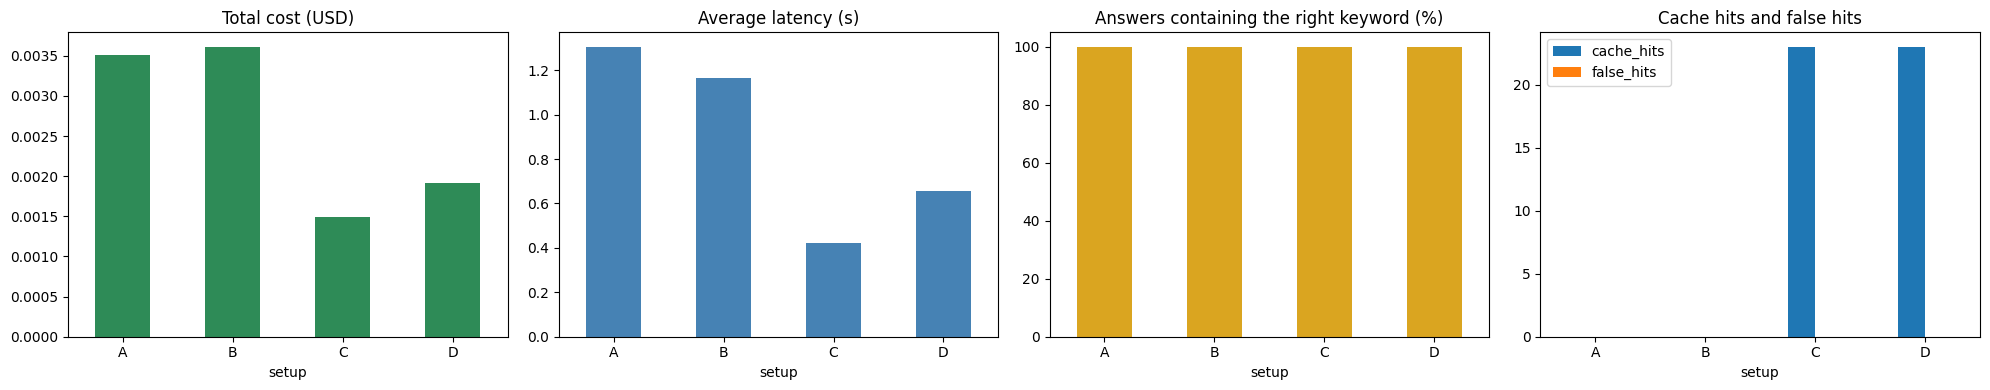

In [7]:
summary = all_logs.groupby("setup").agg(
    queries=("query", "count"),
    total_cost=("cost", "sum"),
    avg_latency_s=("latency", "mean"),
    p95_latency_s=("latency", lambda x: np.percentile(x, 95)),
    correct_answers=("correct", "sum"),
    cache_hits=("hit", "sum"),
    false_hits=("false_hit", "sum"),
    strong_calls=("model", lambda x: (x == STRONG_MODEL).sum()),
    cheap_calls=("model", lambda x: (x == CHEAP_MODEL).sum()),
    escalations=("escalated", "sum"),
)
summary["quality_pct"] = (summary["correct_answers"] / summary["queries"] * 100).round(1)
summary["cost_per_correct"] = summary["total_cost"] / summary["correct_answers"].replace(0, np.nan)
base_cost = summary.loc["A: always strong", "total_cost"]
base_latency = summary.loc["A: always strong", "avg_latency_s"]
base_quality = summary.loc["A: always strong", "quality_pct"]
summary["cost_change_pct"] = ((summary["total_cost"] - base_cost) / base_cost * 100).round(1)
summary["latency_change_pct"] = ((summary["avg_latency_s"] - base_latency) / base_latency * 100).round(1)
summary["quality_change_pts"] = (summary["quality_pct"] - base_quality).round(1)
print(summary.round(6).T)
print("\nNegative cost or latency change = cheaper or faster than always-strong. Negative quality change = more wrong answers.")

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
summary["total_cost"].plot(kind="bar", ax=ax[0], color="seagreen")
ax[0].set_title("Total cost (USD)")
summary["avg_latency_s"].plot(kind="bar", ax=ax[1], color="steelblue")
ax[1].set_title("Average latency (s)")
summary["quality_pct"].plot(kind="bar", ax=ax[2], color="goldenrod")
ax[2].set_title("Answers containing the right keyword (%)")
summary[["cache_hits", "false_hits"]].plot(kind="bar", ax=ax[3])
ax[3].set_title("Cache hits and false hits")
for a in ax:
    a.set_xticklabels([t.get_text().split(":")[0] for t in a.get_xticklabels()], rotation=0)
plt.tight_layout()
plt.show()

## Step 8: Why were answers escalated, and what did the cache get wrong?

In [8]:
b_log = all_logs[all_logs["setup"] == "B: router only"]
esc = b_log[b_log["escalated"]]
print("Escalations in setup B:", len(esc))
if len(esc) > 0:
    print(esc["escalation_reason"].value_counts())
    print("\nIf most reasons say 'empty answer', the cheap model ran out of tokens before answering, so escalation is paying for a wasted call.")

wrong_b = b_log[~b_log["correct"]]
print("\nSetup B answers marked wrong:", len(wrong_b))
if len(wrong_b) > 0:
    print(wrong_b[["query", "model", "answer"]].to_string(index=False))

for name in ["C: router + cache", "D: router + cache + number guard"]:
    log = all_logs[all_logs["setup"] == name]
    bad = log[log["false_hit"]]
    print("\n" + name + " - cache hits:", int(log["hit"].sum()), "| false hits (wrong answer from cache):", len(bad))
    if len(bad) > 0:
        print(bad[["query", "similarity"]].round(3).to_string(index=False))

Escalations in setup B: 3
escalation_reason
too short    3
Name: count, dtype: int64

If most reasons say 'empty answer', the cheap model ran out of tokens before answering, so escalation is paying for a wasted call.

Setup B answers marked wrong: 0

C: router + cache - cache hits: 23 | false hits (wrong answer from cache): 0

D: router + cache + number guard - cache hits: 23 | false hits (wrong answer from cache): 0


## Step 9: Choose the similarity threshold (no API calls)
For each query we find its most similar earlier query. A hit is right if both are in the same group. The last columns show what the number guard changes.

   threshold  hits  correct_hits  false_hits  false_hits_with_number_guard  \
0       0.70    28            26           2                             1   
1       0.75    27            26           1                             0   
2       0.80    27            26           1                             0   
3       0.85    23            23           0                             0   
4       0.90    20            20           0                             0   
5       0.95     5             5           0                             0   

   correct_hits_with_number_guard  
0                              26  
1                              26  
2                              26  
3                              23  
4                              20  
5                               5  

Lowest threshold with zero false hits: 0.85
Lowest threshold with zero false hits when the number guard is on: 0.75


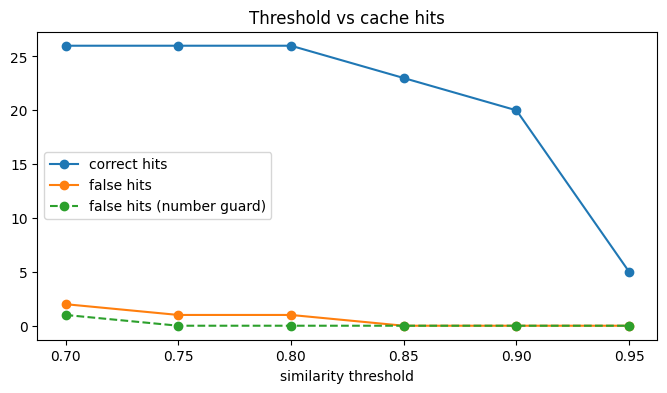

In [9]:
vectors = np.array([embed(q) for q in workload["query"]])
best_sim = []
best_same = []
guard_ok = []
for i in range(len(workload)):
    if i == 0:
        best_sim.append(0.0)
        best_same.append(False)
        guard_ok.append(False)
        continue
    sims = vectors[:i] @ vectors[i]
    j = int(np.argmax(sims))
    best_sim.append(float(sims[j]))
    best_same.append(workload.loc[j, "group"] == workload.loc[i, "group"])
    guard_ok.append(numbers_of(workload.loc[j, "query"]) == numbers_of(workload.loc[i, "query"]))
best_sim = np.array(best_sim)
best_same = np.array(best_same)
guard_ok = np.array(guard_ok)

rows = []
for t in [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    hits = best_sim >= t
    hits_g = hits & guard_ok
    rows.append({"threshold": t, "hits": int(hits.sum()), "correct_hits": int((hits & best_same).sum()), "false_hits": int((hits & ~best_same).sum()),
                 "false_hits_with_number_guard": int((hits_g & ~best_same).sum()), "correct_hits_with_number_guard": int((hits_g & best_same).sum())})
sweep = pd.DataFrame(rows)
print(sweep)

safe = sweep[sweep["false_hits"] == 0]
if len(safe) > 0:
    print("\nLowest threshold with zero false hits:", safe["threshold"].min())
else:
    print("\nNo tested threshold gives zero false hits. A similarity threshold alone is not enough for look-alike questions.")
safe_g = sweep[sweep["false_hits_with_number_guard"] == 0]
if len(safe_g) > 0:
    print("Lowest threshold with zero false hits when the number guard is on:", safe_g["threshold"].min())

plt.figure(figsize=(8, 4))
plt.plot(sweep["threshold"], sweep["correct_hits"], marker="o", label="correct hits")
plt.plot(sweep["threshold"], sweep["false_hits"], marker="o", label="false hits")
plt.plot(sweep["threshold"], sweep["false_hits_with_number_guard"], marker="o", linestyle="--", label="false hits (number guard)")
plt.legend()
plt.title("Threshold vs cache hits")
plt.xlabel("similarity threshold")
plt.show()

## Step 10: Key insights and export

In [10]:
A = summary.loc["A: always strong"]
B = summary.loc["B: router only"]
C = summary.loc["C: router + cache"]
D = summary.loc["D: router + cache + number guard"]
print("KEY INSIGHTS (calculated from this run)")
print("1. Router only: cost", B["cost_change_pct"], "%, latency", B["latency_change_pct"], "%, quality", B["quality_change_pts"], "points vs always-strong")
print("2. Router + cache: cost", C["cost_change_pct"], "%, latency", C["latency_change_pct"], "%, quality", C["quality_change_pts"], "points; false hits:", int(C["false_hits"]))
print("3. With the number guard: cost", D["cost_change_pct"], "%, quality", D["quality_change_pts"], "points; false hits:", int(D["false_hits"]))
print("4. Cost per correct answer (USD):", summary["cost_per_correct"].round(6).to_dict())
if B["cost_change_pct"] > -10:
    print("5. The router saved little here. The cheap and strong models are close in price, or the cheap model wasted calls. Routing only pays off with a big price gap and few escalations.")
else:
    print("5. The router saved a meaningful share of cost. Check the quality change before trusting it.")
print("6. 20 of the 39 queries are repeats or paraphrases by design, so the cache hit rate here is higher than a real workload would give.")
print("7. Only", len(workload), "queries, so treat all percentages as a demo and not a benchmark. Prices are from the pricing sources listed in the notebook header.")

all_logs.to_csv("routing_cache_log.csv", index=False)
summary.to_csv("routing_cache_summary.csv")
sweep.to_csv("routing_cache_threshold_sweep.csv", index=False)
print("\nSaved routing_cache_log.csv, routing_cache_summary.csv, routing_cache_threshold_sweep.csv")

KEY INSIGHTS (calculated from this run)
1. Router only: cost 2.8 %, latency -10.6 %, quality 0.0 points vs always-strong
2. Router + cache: cost -57.5 %, latency -67.8 %, quality 0.0 points; false hits: 0
3. With the number guard: cost -45.5 %, quality 0.0 points; false hits: 0
4. Cost per correct answer (USD): {'A: always strong': 9e-05, 'B: router only': 9.3e-05, 'C: router + cache': 3.8e-05, 'D: router + cache + number guard': 4.9e-05}
5. The router saved little here. The cheap and strong models are close in price, or the cheap model wasted calls. Routing only pays off with a big price gap and few escalations.
6. 20 of the 39 queries are repeats or paraphrases by design, so the cache hit rate here is higher than a real workload would give.
7. Only 39 queries, so treat all percentages as a demo and not a benchmark. Prices are from the pricing sources listed in the notebook header.

Saved routing_cache_log.csv, routing_cache_summary.csv, routing_cache_threshold_sweep.csv



Built by **Akshat Kesharwani** | [GitHub](https://github.com/akshatkesharwani-info) | [Portfolio](https://akshatkesharwani-info.github.io/)